#### FinGraph AI Agent

This project develops an Agentic Financial AI Assistant using LangGraph, Groq LLM, and financial data tool to perform real-time company analysis, financial metric retrieval, and intelligent decision support through natural language interactions.

**Project Vision**

Build an AI-powered financial analyst that can understand natural language queries, retrieve real-time financial data, perform calculations, reason across multiple financial metrics, and generate investment-style insights.

- Requiremenets

1. Langchain openai
2. yfinance
3. pygraphviz

In [1]:
# Import dependancies

import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq

import warnings
warnings.filterwarnings("ignore")

e:\Agents_Langgraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load environment variables
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [3]:
# Initialize the LLM
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.0
)

In [4]:
# Check llm

llm.invoke("What is Finantial AI Agent?")

AIMessage(content='A Financial AI Agent is a type of artificial intelligence (AI) system designed to make decisions and take actions in the financial domain. It is a software program that uses machine learning algorithms, natural language processing, and other AI techniques to analyze financial data, identify patterns, and make predictions or recommendations.\n\nFinancial AI Agents can be used in various applications, such as:\n\n1. **Portfolio management**: AI Agents can analyze market data, identify trends, and make investment decisions to optimize portfolio performance.\n2. **Risk management**: AI Agents can detect potential risks, such as credit defaults or market volatility, and provide alerts or recommendations to mitigate them.\n3. **Trading**: AI Agents can analyze market data, identify trading opportunities, and execute trades automatically.\n4. **Credit scoring**: AI Agents can analyze credit data, predict creditworthiness, and provide credit scores.\n5. **Financial forecasti

In [5]:
# Check yfinance

import yfinance as yf

In [6]:
print(yf.__version__)

1.5.2


In [7]:
def company_address(ticker:str) -> str:
    '''
    Return the registered company address for the given input ticker.
    Example:
    Imput - Ticker: AAPL
    Output - Company address of Apple Inc.
    
    '''
    ticker_obj = yf.Ticker(ticker)
    info = ticker_obj.get_info()
    
    return " ".join([info[key] for key in ['address1','city','state','zip','country']])

In [8]:
company_address("AAPL")

'One Apple Park Way Cupertino CA 95014 United States'

In [9]:
## Defining Tools

from langchain_core.tools import tool, StructuredTool
import yfinance as yf


@tool
def company_address(ticker:str) -> str:
    '''
    Return the registered company address for the given input ticker.
    Example:
    Imput - Ticker: AAPL
    Output - Company address of Apple Inc.
    
    '''
    ticker_obj = yf.Ticker(ticker)
    info = ticker_obj.get_info()
    
    return " ".join([info[key] for key in ['address1','city','state','zip','country']])

@tool
def fulltime_employees(ticker: str) -> int:
    """
    Return the total number of full‑time employees for a given stock ticker.
    Example:  
    Input - Ticker: MSFT  
    Output - Full‑time Employees Count of Microsoft.
    """
    ticker_obj = yf.Ticker(ticker)
    info = ticker_obj.get_info()

    return info['fullTimeEmployees']

@tool
def last_close_price(ticker: str) -> float:
    """
    Return the last closing stock price for a given ticker.  
    Example:  
    Input - Ticker: MSFT  
    Output - Last Close Price of Microsoft.
    """
    ticker_obj = yf.Ticker(ticker)
    info = ticker_obj.get_info()

    return info['previousClose']

@tool
def EBITDA(ticker: str) -> float:
    """
    Return the EBITDA (Earnings Before Interest, Taxes, Depreciation, and Amortization) for a given stock ticker.  
    Example:  
    Input - Ticker: AAPL  
    Output - EBITDA of Apple Inc.
    """
    ticker_obj = yf.Ticker(ticker)
    info = ticker_obj.get_info()

    return info['ebitda']

@tool
def total_debt(ticker: str) -> float:
    """
    Return the total debt for a given stock ticker.  
    Example:  
    Input - Ticker: AAPL  
    Output - Total Debt of Apple Inc.
    """
    ticker_obj = yf.Ticker(ticker)
    info = ticker_obj.get_info()

    return info['totalDebt']

@tool
def total_revenue(ticker: str) -> float:
    """
    Return the total revenue for a given stock ticker.  
    Example:  
    Input - Ticker: MSFT  
    Output - Total Revenue of Microsoft.
    """
    ticker_obj = yf.Ticker(ticker)
    info = ticker_obj.get_info()

    return info['totalRevenue']

@tool
def debt_to_equity_ratio(ticker: str) -> float:
    """
    Return the debt‑to‑equity ratio for a given stock ticker.  
    Example:  
    Input - Ticker: AAPL  
    Output - Debt‑to‑Equity Ratio of Apple Inc.
    """
    ticker_obj = yf.Ticker(ticker)
    info = ticker_obj.get_info()

    return info['debtToEquity']

tools = [
    company_address,
    fulltime_employees,
    last_close_price,
    EBITDA,
    total_debt,
    total_revenue,
    debt_to_equity_ratio
]

In [10]:
debt_to_equity_ratio

StructuredTool(name='debt_to_equity_ratio', description='Return the debt‑to‑equity ratio for a given stock ticker.  \nExample:  \nInput - Ticker: AAPL  \nOutput - Debt‑to‑Equity Ratio of Apple Inc.', args_schema=<class 'langchain_core.utils.pydantic.debt_to_equity_ratio'>, func=<function debt_to_equity_ratio at 0x00000242BD4D07C0>)

In [11]:
print(debt_to_equity_ratio.name)
print(debt_to_equity_ratio.description)
print(debt_to_equity_ratio.args_schema)

debt_to_equity_ratio
Return the debt‑to‑equity ratio for a given stock ticker.  
Example:  
Input - Ticker: AAPL  
Output - Debt‑to‑Equity Ratio of Apple Inc.
<class 'langchain_core.utils.pydantic.debt_to_equity_ratio'>


In [12]:
llm_with_tools = llm.bind_tools(tools, tool_choice='auto')

In [13]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000242B9A77A10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000242B9B397D0>, model_name='llama-3.1-8b-instant', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'company_address', 'descript

In [14]:
ai_response = llm_with_tools.invoke('Whatzzz up??')

print(ai_response.content)
print(ai_response.tool_calls)

I'm here to help with any questions or tasks you have. What's on your mind?
[]


In [15]:
ai_response = llm_with_tools.invoke("What's the EBITDA of Microsoft?")


print(ai_response.tool_calls)

[{'name': 'EBITDA', 'args': {'ticker': 'MSFT'}, 'id': '0t7m1qcks', 'type': 'tool_call'}]


In [16]:
print(ai_response.content)

In [18]:
# Dependancies for workflow

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages, AnyMessage
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import display, Image

In [19]:
# State Definations
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [20]:
# System Propmts

system_prompt = '''You are an Intelligent finance assistant have more that 15 years of experience.  
Use the available tools to provide accurate answers.  
You may make multiple calls, either in parallel or sequentially.  
If additional information is required before asking a follow‑up, you are allowed to look it up first.'''

In [21]:
# Define the llm node

def tool_calling_llm(state: AgentState):
    
    state_messages = state["messages"]
    
    messages = [
        SystemMessage(content=system_prompt)
    ] + state_messages
    
    response = llm_with_tools.invoke(messages)
    
    return {
        "messages":[response]
        }

In [22]:
# Define the state graph
builder = StateGraph(AgentState)

# Add nodes

builder.add_node("llm_node",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))


# Add the edges
builder.add_edge(START, "llm_node")
builder.add_conditional_edges("llm_node", tools_condition)
builder.add_edge("tools", "llm_node")

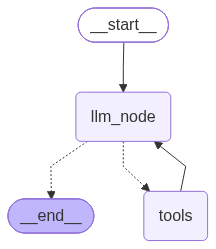

In [23]:
# Define LangGraph Memory

from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()

graph_memory = builder.compile(checkpointer=memory, name="react_agent_with_memory")

display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [24]:
config = {"configurable":{"thread_id":"1"}}

messages = [HumanMessage(content="What's up Llama 3.1 8B?")]

messages = graph_memory.invoke({"messages":messages}, config=config)

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What's up Llama 3.1 8B?
================================== Ai Message ==================================

I'm functioning within normal parameters. How can I assist you today?


In [25]:
messages

{'messages': [HumanMessage(content="What's up Llama 3.1 8B?", additional_kwargs={}, response_metadata={}, id='77536ea2-fe02-4154-80c2-17d1a596151b'),
  AIMessage(content="I'm functioning within normal parameters. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 1040, 'total_tokens': 1055, 'completion_time': 0.026691197, 'completion_tokens_details': None, 'prompt_time': 0.067173442, 'prompt_tokens_details': None, 'queue_time': 0.159228857, 'total_time': 0.093864639}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019feb21-f79e-76e3-9e68-a6db2c1d9af5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1040, 'output_tokens': 15, 'total_tokens': 1055})]}

In [26]:
config = {"configurable":{"thread_id":"1"}}

messages = [HumanMessage(content="What is the EBITDA of Nvidia?")]

messages = graph_memory.invoke({"messages":messages}, config=config)

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What's up Llama 3.1 8B?
================================== Ai Message ==================================

I'm functioning within normal parameters. How can I assist you today?
================================ Human Message =================================

What is the EBITDA of Nvidia?
================================== Ai Message ==================================
Tool Calls:
  EBITDA (7phpkm1pb)
 Call ID: 7phpkm1pb
  Args:
    ticker: NVDA
================================= Tool Message =================================
Name: EBITDA

165514002432
================================== Ai Message ==================================

The EBITDA of Nvidia is $165,514,002,432.


In [27]:
config = {"configurable":{"thread_id":"1"}}

messages = [HumanMessage(content="What is the status of full time employees of AAPL?")]

messages = graph_memory.invoke({"messages":messages}, config=config)

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What's up Llama 3.1 8B?
================================== Ai Message ==================================

I'm functioning within normal parameters. How can I assist you today?
================================ Human Message =================================

What is the EBITDA of Nvidia?
================================== Ai Message ==================================
Tool Calls:
  EBITDA (7phpkm1pb)
 Call ID: 7phpkm1pb
  Args:
    ticker: NVDA
================================= Tool Message =================================
Name: EBITDA

165514002432
================================== Ai Message ==================================

The EBITDA of Nvidia is $165,514,002,432.
================================ Human Message =================================

What is the status of full time employees of AAPL?
================================== Ai Message ==================================
Tool Calls:
  fulltime_em

In [28]:
config = {"configurable":{"thread_id":"1"}}

messages = [HumanMessage(content="What is  total debt value of  NFLX?")]

messages = graph_memory.invoke({"messages":messages}, config=config)

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What's up Llama 3.1 8B?
================================== Ai Message ==================================

I'm functioning within normal parameters. How can I assist you today?
================================ Human Message =================================

What is the EBITDA of Nvidia?
================================== Ai Message ==================================
Tool Calls:
  EBITDA (7phpkm1pb)
 Call ID: 7phpkm1pb
  Args:
    ticker: NVDA
================================= Tool Message =================================
Name: EBITDA

165514002432
================================== Ai Message ==================================

The EBITDA of Nvidia is $165,514,002,432.
================================ Human Message =================================

What is the status of full time employees of AAPL?
================================== Ai Message ==================================
Tool Calls:
  fulltime_em

In [29]:
config = {"configurable":{"thread_id":"2"}}

messages = [HumanMessage(content="What is the status of full time employees of AAPL?")]

messages = graph_memory.invoke({"messages":messages}, config=config)

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is the status of full time employees of AAPL?
================================== Ai Message ==================================
Tool Calls:
  fulltime_employees (1zce8mxe4)
 Call ID: 1zce8mxe4
  Args:
    ticker: AAPL
  company_address (pdfdkjata)
 Call ID: pdfdkjata
  Args:
    ticker: AAPL
================================= Tool Message =================================
Name: fulltime_employees

150000
================================= Tool Message =================================
Name: company_address

One Apple Park Way Cupertino CA 95014 United States
================================== Ai Message ==================================

The current status of full-time employees of AAPL is 150,000. The company address is One Apple Park Way, Cupertino, CA 95014, United States.
